# Project: How and where do different SAE architecture recover feature topology?

In [1]:
from abc import ABC, abstractmethod
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from ripser import ripser
import persim

In [2]:
class TopologicalSpace(ABC):
    def __init__(self, dimension: int, noise_level: float):
        self.dimension = dimension
        self.noise_level = noise_level

    @abstractmethod
    def sample(self, n: int) -> np.ndarray:
        """Sample `n` points from the space."""
        pass


class Circle(TopologicalSpace):
    def __init__(self, dimension: int, noise_level: float, center: np.ndarray):
        super().__init__(dimension, noise_level)
        self.center = center
        self.u, self.v = self._generate_span()

    def sample(self, n: int) -> np.ndarray:
        """Sample `n` points uniformly at random along the circle of radius 1."""
        thetas = np.random.uniform(0, 2 * np.pi, n)
        coords = np.outer(np.cos(thetas), self.u) + np.outer(np.sin(thetas), self.v)
        return coords + self.center + np.random.randn(n, self.dimension) * self.noise_level

    def _generate_span(self):
        """Return two orthonormal vectors that span the plane of the circle."""
        dim = self.dimension
        u = np.random.randn(dim)
        u /= np.linalg.norm(u)

        v = np.random.randn(dim)
        v -= v.dot(u) * u
        v /= np.linalg.norm(v)

        return u, v

In [3]:
class Points(TopologicalSpace):
    """k isolated Gaussian point-clouds in R^d. Expected: H_0=k, H_1=0."""

    def __init__(self, dimension: int, noise_level: float, n_points: int = 3, spread: float = 5.0):
        super().__init__(dimension, noise_level)
        self.n_points = n_points
        # Place cluster centers far enough apart to be clearly separated
        centers = []
        for _ in range(n_points):
            direction = np.random.randn(dimension)
            direction /= np.linalg.norm(direction)
            centers.append(direction * spread)
        self.centers = np.array(centers)

    def sample(self, n: int) -> np.ndarray:
        """Sample n points (~n//k per cluster) with Gaussian noise around each center."""
        k = self.n_points
        points = []
        for i, center in enumerate(self.centers):
            # distribute points as evenly as possible
            n_i = n // k if i < k - 1 else n - (n // k) * (k - 1)
            cluster_pts = center + np.random.randn(n_i, self.dimension) * self.noise_level
            points.append(cluster_pts)
        return np.vstack(points)

In [4]:
class TwoCircles(TopologicalSpace):
    """Two disjoint circles at a given separation. Expected: H_0=2, H_1=2."""

    def __init__(self, dimension: int, noise_level: float, center: np.ndarray,
                 separation: float = 5.0, radii: tuple = (1.0, 1.0)):
        super().__init__(dimension, noise_level)
        self.radii = radii

        # First circle centered at `center`
        self.c1 = np.array(center, dtype=float)

        # Second circle center displaced from c1 along a random unit vector
        direction = np.random.randn(dimension)
        direction /= np.linalg.norm(direction)
        self.c2 = self.c1 + separation * direction

        # Independent Gram-Schmidt bases for each circle
        self.u1, self.v1 = self._gram_schmidt_basis()
        self.u2, self.v2 = self._gram_schmidt_basis()

    def _gram_schmidt_basis(self):
        dim = self.dimension
        u = np.random.randn(dim)
        u /= np.linalg.norm(u)
        v = np.random.randn(dim)
        v -= v.dot(u) * u
        v /= np.linalg.norm(v)
        return u, v

    def sample(self, n: int) -> np.ndarray:
        """Sample n//2 points from each circle, stacked."""
        n1 = n // 2
        n2 = n - n1

        t1 = np.random.uniform(0, 2 * np.pi, n1)
        pts1 = (self.radii[0] * np.outer(np.cos(t1), self.u1)
                + self.radii[0] * np.outer(np.sin(t1), self.v1)
                + self.c1
                + np.random.randn(n1, self.dimension) * self.noise_level)

        t2 = np.random.uniform(0, 2 * np.pi, n2)
        pts2 = (self.radii[1] * np.outer(np.cos(t2), self.u2)
                + self.radii[1] * np.outer(np.sin(t2), self.v2)
                + self.c2
                + np.random.randn(n2, self.dimension) * self.noise_level)

        return np.vstack([pts1, pts2])

In [5]:
class FigureEight(TopologicalSpace):
    """Two circles sharing a wedge point. Expected: H_0=1, H_1=2.

    Construction: lobe i has center = wedge + radius * u_i.  At theta=pi,
    center_i + radius*cos(pi)*u_i = wedge, so both lobes pass through `center`.
    u1 and u2 are orthogonal (Gram-Schmidt) so the lobes extend in different
    directions from the wedge.
    """

    def __init__(self, dimension: int, noise_level: float, center: np.ndarray, radius: float = 1.0):
        super().__init__(dimension, noise_level)
        self.wedge = np.array(center, dtype=float)
        self.radius = radius

        # Primary axis for lobe 1
        u1 = np.random.randn(dimension)
        u1 /= np.linalg.norm(u1)

        # Orthogonal axis for lobe 2 (Gram-Schmidt)
        u2 = np.random.randn(dimension)
        u2 -= u2.dot(u1) * u1
        u2 /= np.linalg.norm(u2)

        # Each lobe needs a second in-plane direction for the circle parametrization
        v1 = np.random.randn(dimension)
        v1 -= v1.dot(u1) * u1
        v1 /= np.linalg.norm(v1)

        v2 = np.random.randn(dimension)
        v2 -= v2.dot(u2) * u2
        v2 -= v2.dot(u1) * u1  # also orthogonal to u1 (keeps lobes separated)
        norm2 = np.linalg.norm(v2)
        if norm2 < 1e-8:
            v2 = np.random.randn(dimension)
            v2 -= v2.dot(u2) * u2
            v2 /= np.linalg.norm(v2)
        else:
            v2 /= norm2

        self.u1, self.v1 = u1, v1
        self.u2, self.v2 = u2, v2
        # Lobe centers are offset from the wedge along u_i
        self.c1 = self.wedge + radius * u1
        self.c2 = self.wedge + radius * u2

    def sample(self, n: int) -> np.ndarray:
        """Sample n//2 points from each lobe using random angles."""
        n1 = n // 2
        n2 = n - n1

        t1 = np.random.uniform(0, 2 * np.pi, n1)
        pts1 = (self.radius * np.outer(np.cos(t1), self.u1)
                + self.radius * np.outer(np.sin(t1), self.v1)
                + self.c1
                + np.random.randn(n1, self.dimension) * self.noise_level)

        t2 = np.random.uniform(0, 2 * np.pi, n2)
        pts2 = (self.radius * np.outer(np.cos(t2), self.u2)
                + self.radius * np.outer(np.sin(t2), self.v2)
                + self.c2
                + np.random.randn(n2, self.dimension) * self.noise_level)

        return np.vstack([pts1, pts2])

In [6]:
def make_dgp(topology: str, d: int, sigma: float, c0: np.ndarray, N: int, **kwargs) -> TopologicalSpace:
    """Factory function returning the appropriate TopologicalSpace.

    Args:
        topology: one of 'points', 'circle', 'two_circles', 'figure_eight'
        d: ambient dimension
        sigma: noise level
        c0: center (array of shape (d,))
        N: number of points to sample (not used here; caller uses dgp.sample(N))
        **kwargs: topology-specific parameters:
            - 'points':       n_points (int), spread (float)
            - 'two_circles':  separation (float), radii (tuple)
            - 'figure_eight': radius (float)
    """
    c0 = np.asarray(c0, dtype=float)
    if topology == 'points':
        return Points(d, sigma, n_points=kwargs.get('n_points', 3), spread=kwargs.get('spread', 5.0))
    elif topology == 'circle':
        return Circle(d, sigma, c0)
    elif topology == 'two_circles':
        return TwoCircles(d, sigma, c0,
                          separation=kwargs.get('separation', 5.0),
                          radii=kwargs.get('radii', (1.0, 1.0)))
    elif topology == 'figure_eight':
        return FigureEight(d, sigma, c0, radius=kwargs.get('radius', 1.0))
    else:
        raise ValueError(f"Unknown topology '{topology}'. "
                         "Choose from: 'points', 'circle', 'two_circles', 'figure_eight'.")

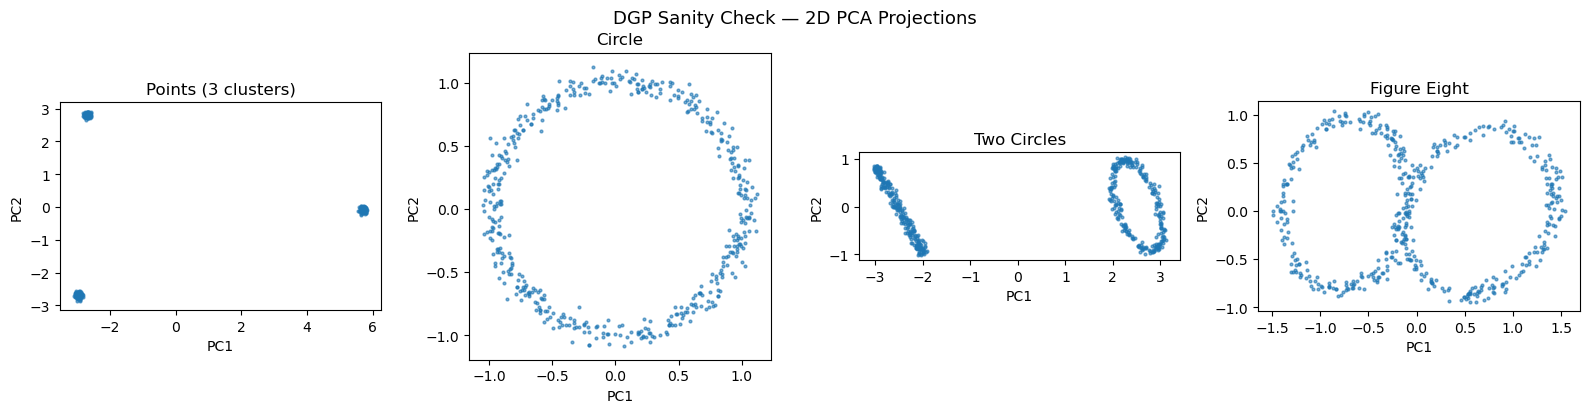

In [7]:
# Cell 8 — DGP sanity check: 2D PCA projections of each topology
np.random.seed(42)
d, sigma, N = 8, 0.05, 500
c0 = np.zeros(d)

topologies = ['points', 'circle', 'two_circles', 'figure_eight']
titles = ['Points (3 clusters)', 'Circle', 'Two Circles', 'Figure Eight']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, topo, title in zip(axes, topologies, titles):
    dgp = make_dgp(topo, d, sigma, c0, N)
    X = dgp.sample(N)
    # Project to 2D via PCA for visualization
    X2d = PCA(n_components=2).fit_transform(X)
    ax.scatter(X2d[:, 0], X2d[:, 1], s=4, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_aspect('equal')

plt.suptitle('DGP Sanity Check — 2D PCA Projections', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# Cell 9 — PH pipeline

def compute_ph(X: np.ndarray, max_dim: int = 1, metric: str = 'euclidean',
               thresh: float = None, n_perm: int = None) -> dict:
    """Compute persistent homology of point cloud X via Vietoris-Rips.

    Args:
        X: point cloud, shape (n, d)
        max_dim: maximum homology dimension (default 1, so H_0 and H_1)
        metric: 'euclidean' or 'cosine'
        thresh: max edge length for ripser (None = automatic)
        n_perm: number of landmark points for approximate PH (None = exact)

    Returns dict with keys:
        'dgms'      : list of ndarray, one per dimension (birth/death pairs)
        'metric'    : metric used
        'n_points'  : number of input points
        'num_edges' : number of edges in the filtration (from ripser output)
    """
    kwargs = dict(maxdim=max_dim, metric=metric)
    if thresh is not None:
        kwargs['thresh'] = thresh
    if n_perm is not None:
        kwargs['n_perm'] = n_perm

    result = ripser(X, **kwargs)
    return {
        'dgms': result['dgms'],
        'metric': metric,
        'n_points': X.shape[0],
        'num_edges': result.get('num_edges', None),
    }


def filter_diagram(dgm: np.ndarray, min_persistence: float = 0.0,
                   remove_inf: bool = False) -> np.ndarray:
    """Filter a persistence diagram.

    Args:
        dgm: ndarray of shape (k, 2) with birth/death pairs
        min_persistence: remove features with death - birth <= min_persistence
        remove_inf: if True, also remove rows where death == inf

    Returns filtered ndarray.
    """
    if dgm.shape[0] == 0:
        return dgm
    persistence = dgm[:, 1] - dgm[:, 0]
    mask = persistence > min_persistence
    if remove_inf:
        mask &= np.isfinite(dgm[:, 1])
    return dgm[mask]


def summarize_ph(dgms: list, min_persistence: float = 0.0) -> dict:
    """Summarize persistence diagrams.

    Betti number convention:
      - H_0: the essential class (infinite bar) is always present, so
        betti[0] = 1 + number of finite H_0 bars above threshold.
      - H_k (k>=1): betti[k] = number of finite bars above threshold.

    Returns dict:
        'betti'     : list[int], one per dimension
        'max_pers'  : list[float], max finite persistence per dimension
        'total_pers': list[float], sum of finite persistences per dimension
        'diagrams'  : the filtered diagrams
    """
    betti = []
    max_pers = []
    total_pers = []
    filtered = []

    for dim, dgm in enumerate(dgms):
        finite = filter_diagram(dgm, min_persistence=min_persistence, remove_inf=True)
        filtered.append(finite)

        count = len(finite)
        if dim == 0:
            # H_0 always has one essential class
            betti.append(1 + count)
        else:
            betti.append(count)

        if count > 0:
            pers = finite[:, 1] - finite[:, 0]
            max_pers.append(float(np.max(pers)))
            total_pers.append(float(np.sum(pers)))
        else:
            max_pers.append(0.0)
            total_pers.append(0.0)

    return {
        'betti': betti,
        'max_pers': max_pers,
        'total_pers': total_pers,
        'diagrams': filtered,
    }

In [9]:
# Cell 10 — Normalized H1 persistence (rho)

def normalized_h1_persistence(dgms: list, min_persistence: float = 0.0) -> float:
    """Compute rho = sum(finite H_1 lifetimes) / max(finite H_0 death times).

    This provides a scale-normalized measure of how much H_1 signal exists.
    H_0 finite death times reflect the scale at which clusters merge, serving
    as a natural scale proxy for the data.

    Returns nan if:
      - No finite H_0 bars (denominator = 0)
      - No finite H_1 bars above min_persistence
    """
    if len(dgms) < 2:
        return float('nan')

    # H_0 finite bars (remove the essential infinite bar)
    h0_finite = filter_diagram(dgms[0], min_persistence=0.0, remove_inf=True)
    if len(h0_finite) == 0:
        return float('nan')
    denom = float(np.max(h0_finite[:, 1]))  # max death time in H_0
    if denom < 1e-12:
        return float('nan')

    # H_1 finite bars above threshold
    h1_finite = filter_diagram(dgms[1], min_persistence=min_persistence, remove_inf=True)
    if len(h1_finite) == 0:
        return float('nan')

    numerator = float(np.sum(h1_finite[:, 1] - h1_finite[:, 0]))
    return numerator / denom

In [10]:
# Cell 11 — Bottleneck distance

def bottleneck_distance(dgm1: np.ndarray, dgm2: np.ndarray) -> float:
    """Compute bottleneck distance between two persistence diagrams.

    Both diagrams must already have inf values removed (use filter_diagram
    with remove_inf=True before calling this function).

    Handles empty diagrams by substituting np.zeros((0, 2)).
    """
    d1 = dgm1 if dgm1.shape[0] > 0 else np.zeros((0, 2))
    d2 = dgm2 if dgm2.shape[0] > 0 else np.zeros((0, 2))
    # persim.bottleneck expects finite diagrams
    return float(persim.bottleneck(d1, d2))


def bottleneck_distance_to_reference(dgms_computed: list, dgms_reference: list,
                                      dim: int = 1, min_persistence: float = 0.0) -> float:
    """Bottleneck distance between computed and reference diagrams in dimension `dim`.

    Filters both diagrams (removes inf, applies min_persistence threshold)
    before computing distance.
    """
    dgm_c = filter_diagram(dgms_computed[dim], min_persistence=min_persistence, remove_inf=True)
    dgm_r = filter_diagram(dgms_reference[dim], min_persistence=min_persistence, remove_inf=True)
    return bottleneck_distance(dgm_c, dgm_r)

In [11]:
# Cell 12 — Validation helpers + suite

def _sample_line_segment(d: int, n: int, sigma: float) -> np.ndarray:
    """Sample n noisy points along a random line segment in R^d (t ~ Uniform[0,1])."""
    direction = np.random.randn(d)
    direction /= np.linalg.norm(direction)
    t = np.random.uniform(0, 1, n)
    return np.outer(t, direction) + np.random.randn(n, d) * sigma


def _sample_sphere(d: int, n: int, sigma: float, embed_dim: int = 3) -> np.ndarray:
    """Sample n noisy points on S^2 embedded in R^d (embed_dim <= d).

    Normalizes 3D Gaussian samples onto the unit sphere, then zero-pads to R^d.
    Expected: H_0=1, H_1=0 (H_2=1 is not visible at max_dim=1).
    """
    raw = np.random.randn(n, embed_dim)
    raw /= np.linalg.norm(raw, axis=1, keepdims=True)
    if d > embed_dim:
        pad = np.zeros((n, d - embed_dim))
        raw = np.hstack([raw, pad])
    return raw + np.random.randn(n, d) * sigma


# Expected Betti numbers per topology (H_0 convention: 1 + finite H_0 bars)
VALIDATION_CONFIGS = {
    'line_segment': {'expected_H0': 1, 'expected_H1': 0, 'sampler': 'line_segment'},
    'circle':       {'expected_H0': 1, 'expected_H1': 1, 'sampler': 'circle'},
    'sphere':       {'expected_H0': 1, 'expected_H1': 0, 'sampler': 'sphere'},   # H_2 invisible at max_dim=1
    'two_circles':  {'expected_H0': 2, 'expected_H1': 2, 'sampler': 'two_circles'},
    'figure_eight': {'expected_H0': 1, 'expected_H1': 2, 'sampler': 'figure_eight'},
}


def run_validation_suite(d: int = 8, sigma: float = 0.05, N: int = 500,
                          thresh: float = 4.0, min_persistence_frac: float = 0.1,
                          verbose: bool = True) -> dict:
    """Run PH validation on all 5 reference topologies.

    min_persistence_frac: persistence threshold as fraction of data diameter.
    Returns dict with per-topology results and '_all_passed' bool.
    """
    np.random.seed(0)
    c0 = np.zeros(d)
    results = {}

    for name, cfg in VALIDATION_CONFIGS.items():
        sampler = cfg['sampler']

        # Generate point cloud
        if sampler == 'line_segment':
            X = _sample_line_segment(d, N, sigma)
        elif sampler == 'circle':
            X = make_dgp('circle', d, sigma, c0, N).sample(N)
        elif sampler == 'sphere':
            X = _sample_sphere(d, N, sigma)
        elif sampler == 'two_circles':
            X = make_dgp('two_circles', d, sigma, c0, N, separation=5.0).sample(N)
        elif sampler == 'figure_eight':
            X = make_dgp('figure_eight', d, sigma, c0, N, radius=1.0).sample(N)
        else:
            raise ValueError(f"Unknown sampler: {sampler}")

        # Adaptive min_persistence based on data diameter
        diam = float(np.max(np.linalg.norm(X - X.mean(0), axis=1))) * 2
        min_pers = min_persistence_frac * diam

        ph = compute_ph(X, max_dim=1, thresh=thresh)
        summary = summarize_ph(ph['dgms'], min_persistence=min_pers)

        got_H0 = summary['betti'][0]
        got_H1 = summary['betti'][1] if len(summary['betti']) > 1 else 0
        exp_H0 = cfg['expected_H0']
        exp_H1 = cfg['expected_H1']
        passed = (got_H0 == exp_H0) and (got_H1 == exp_H1)

        results[name] = {
            'X': X,
            'ph': ph,
            'summary': summary,
            'expected_H0': exp_H0,
            'expected_H1': exp_H1,
            'got_H0': got_H0,
            'got_H1': got_H1,
            'passed': passed,
            'min_persistence': min_pers,
        }

        if verbose:
            status = 'PASS' if passed else 'FAIL'
            print(f"[{status}] {name:15s}  "
                  f"H0: expected={exp_H0}, got={got_H0}  |  "
                  f"H1: expected={exp_H1}, got={got_H1}  |  "
                  f"min_pers={min_pers:.3f}")

    all_passed = all(r['passed'] for r in results.values())
    results['_all_passed'] = all_passed
    if verbose:
        print(f"\n{'All tests passed!' if all_passed else 'Some tests FAILED.'}")

    return results

[FAIL] line_segment     H0: expected=1, got=78  |  H1: expected=0, got=0  |  min_pers=0.117
[PASS] circle           H0: expected=1, got=1  |  H1: expected=1, got=1  |  min_pers=0.234
[FAIL] sphere           H0: expected=1, got=44  |  H1: expected=0, got=3  |  min_pers=0.232
[PASS] two_circles      H0: expected=2, got=2  |  H1: expected=2, got=2  |  min_pers=0.684
[PASS] figure_eight     H0: expected=1, got=1  |  H1: expected=2, got=2  |  min_pers=0.337

Some tests FAILED.


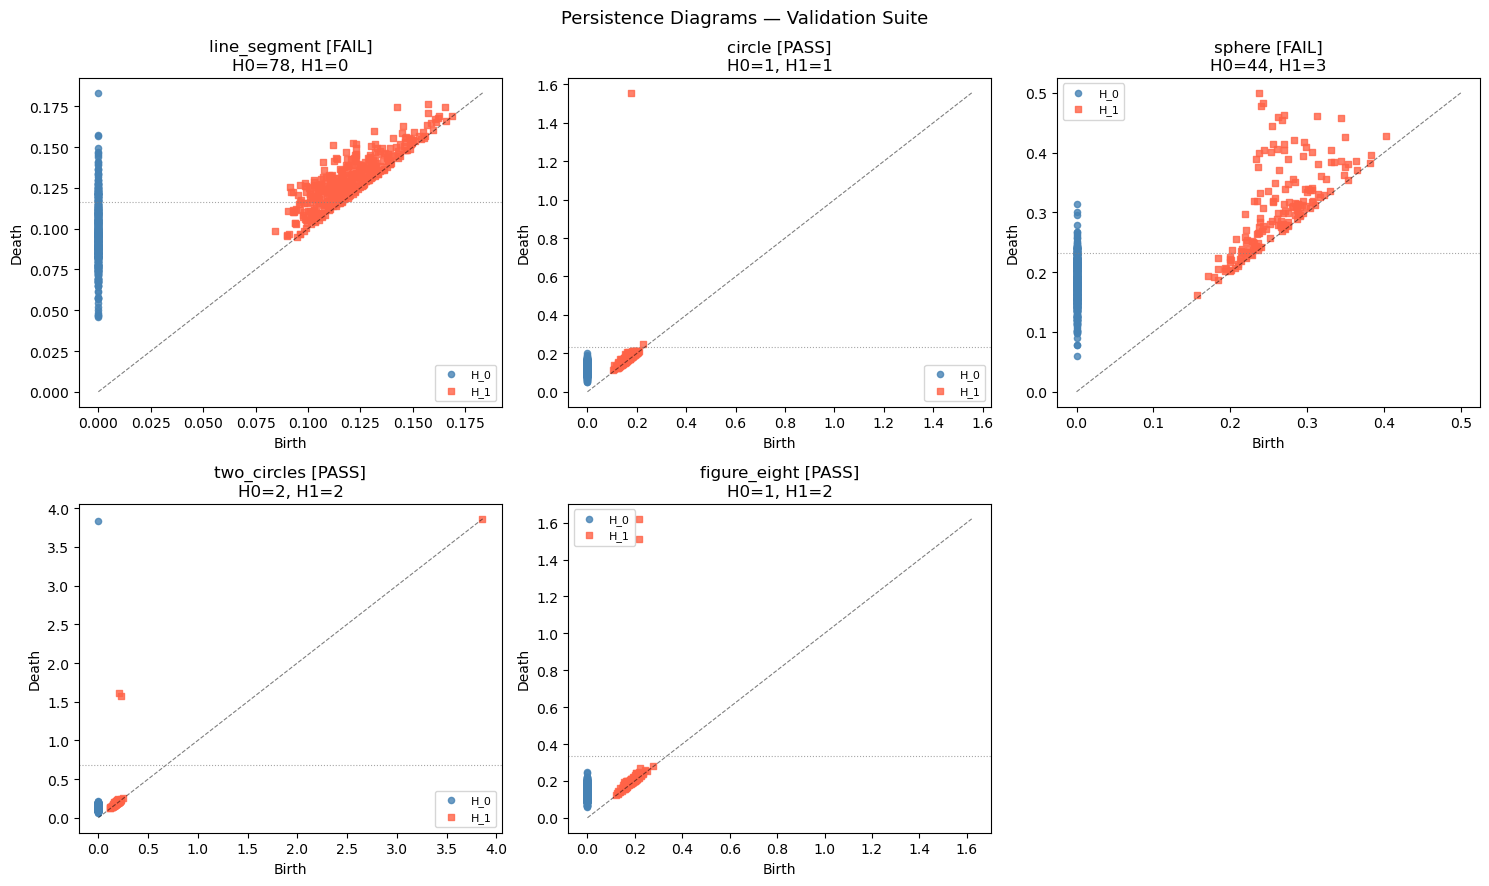

In [12]:
# Cell 13 — Run validation suite + persistence diagram plots

results = run_validation_suite(d=8, sigma=0.05, N=500)

# Plot persistence diagrams in a 2x3 grid
topo_names = list(VALIDATION_CONFIGS.keys())
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flatten()

for i, name in enumerate(topo_names):
    ax = axes_flat[i]
    r = results[name]
    dgms = r['ph']['dgms']
    min_pers = r['min_persistence']

    # Plot H_0 and H_1 diagrams
    colors = ['steelblue', 'tomato']
    markers = ['o', 's']
    for dim in range(min(2, len(dgms))):
        dgm = dgms[dim]
        finite_mask = np.isfinite(dgm[:, 1])
        finite = dgm[finite_mask]
        if len(finite) > 0:
            ax.scatter(finite[:, 0], finite[:, 1], c=colors[dim],
                       marker=markers[dim], s=20, label=f'H_{dim}', alpha=0.8)

    # Diagonal reference line
    all_finite = np.concatenate([dgms[d][np.isfinite(dgms[d][:, 1])] for d in range(min(2, len(dgms)))
                                  if len(dgms[d]) > 0], axis=0) if any(len(dgms[d]) > 0 for d in range(min(2, len(dgms)))) else np.zeros((1, 2))
    lo = all_finite.min() if len(all_finite) > 0 else 0
    hi = all_finite.max() if len(all_finite) > 0 else 1
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)

    # Mark min_persistence threshold
    ax.axhline(y=lo + min_pers, color='gray', linestyle=':', lw=0.8, alpha=0.7)

    status = 'PASS' if r['passed'] else 'FAIL'
    ax.set_title(f"{name} [{status}]\nH0={r['got_H0']}, H1={r['got_H1']}")
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.legend(fontsize=8)

# Hide unused subplot
axes_flat[-1].set_visible(False)

plt.suptitle('Persistence Diagrams — Validation Suite', fontsize=13)
plt.tight_layout()
plt.show()

Computing reference PH diagrams (low-noise, N=1000)...

Reference PH verification:
  [OK] points           H0: gt=3 got=3  |  H1: gt=0 got=0  |  min_pers=0.170
  [OK] circle           H0: gt=1 got=1  |  H1: gt=1 got=1  |  min_pers=0.170
  [OK] two_circles      H0: gt=2 got=2  |  H1: gt=2 got=2  |  min_pers=0.170
  [OK] figure_eight     H0: gt=1 got=1  |  H1: gt=2 got=2  |  min_pers=0.170


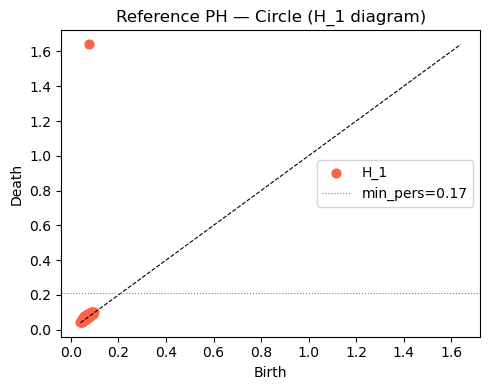

In [13]:
# Cell 14 — Reference PH + ground truth

GROUND_TRUTH_BETTI = {
    'points':       {'H0': 3, 'H1': 0},
    'circle':       {'H0': 1, 'H1': 1},
    'two_circles':  {'H0': 2, 'H1': 2},
    'figure_eight': {'H0': 1, 'H1': 2},
}


def compute_reference_ph(topology: str, d: int = 8, sigma: float = 0.02,
                          N_ref: int = 1000, max_edge_length: float = None) -> dict:
    """Generate a large low-noise sample from make_dgp and compute PH.

    Returns dict with keys: 'dgms', 'topology', 'params', 'min_persistence'.
    min_persistence is the noise-floor threshold recommended for this sample:
        3 * sigma * sqrt(d)
    """
    c0 = np.zeros(d)
    extra = {}
    if topology == 'points':
        extra = {'n_points': 3, 'spread': 5.0}
    elif topology == 'two_circles':
        extra = {'separation': 5.0}
    elif topology == 'figure_eight':
        extra = {'radius': 1.0}

    dgp = make_dgp(topology, d, sigma, c0, N_ref, **extra)
    X = dgp.sample(N_ref)

    ph = compute_ph(X, max_dim=1, thresh=max_edge_length)
    # Noise-calibrated persistence floor: same formula as run_validation_suite
    min_pers = 3.0 * sigma * np.sqrt(d)
    return {
        'dgms': ph['dgms'],
        'topology': topology,
        'params': {'d': d, 'sigma': sigma, 'N_ref': N_ref},
        'min_persistence': min_pers,
    }


# Generate and cache reference diagrams for all 4 DGP topologies
print("Computing reference PH diagrams (low-noise, N=1000)...")
np.random.seed(1)
ref_phs = {t: compute_reference_ph(t) for t in GROUND_TRUTH_BETTI}

# Verify against ground truth using the noise-floor threshold from each reference
print("\nReference PH verification:")
for topo, ref in ref_phs.items():
    gt = GROUND_TRUTH_BETTI[topo]
    min_pers = ref['min_persistence']
    summary = summarize_ph(ref['dgms'], min_persistence=min_pers)
    got_H0 = summary['betti'][0]
    got_H1 = summary['betti'][1] if len(summary['betti']) > 1 else 0
    ok_H0 = (got_H0 == gt['H0'])
    ok_H1 = (got_H1 == gt['H1'])
    status = 'OK' if (ok_H0 and ok_H1) else 'CHECK'
    print(f"  [{status}] {topo:15s}  H0: gt={gt['H0']} got={got_H0}  |  "
          f"H1: gt={gt['H1']} got={got_H1}  |  min_pers={min_pers:.3f}")

# Plot reference diagram for 'circle' — should show a single prominent H_1 bar
ref_circle = ref_phs['circle']
min_pers_circle = ref_circle['min_persistence']
fig, ax = plt.subplots(figsize=(5, 4))
dgm_h1 = ref_circle['dgms'][1]
finite_h1 = dgm_h1[np.isfinite(dgm_h1[:, 1])]
if len(finite_h1) > 0:
    ax.scatter(finite_h1[:, 0], finite_h1[:, 1], c='tomato', s=40, label='H_1')
lo = float(finite_h1.min()) if len(finite_h1) > 0 else 0.0
hi = float(finite_h1.max()) if len(finite_h1) > 0 else 1.0
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
ax.axhline(y=lo + min_pers_circle, color='gray', linestyle=':', lw=0.8,
           label=f'min_pers={min_pers_circle:.2f}')
ax.set_title("Reference PH — Circle (H_1 diagram)")
ax.set_xlabel('Birth')
ax.set_ylabel('Death')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Cell 15 — T1/T2 score

def t1_t2_score(rho_t1: float, rho_t2: float, epsilon: float = 1e-8) -> float:
    """T1/T2 score: rho_t1 / (rho_t1 + rho_t2).

    Returns:
        float in [0, 1]: closer to 1 → T1-dominant (topology in decoder atoms)
                         closer to 0 → T2-dominant (topology in sparse codes)
        nan if both rho values are near zero or nan.
    """
    if (np.isnan(rho_t1) and np.isnan(rho_t2)):
        return float('nan')
    # Treat nan as 0 for the sum
    r1 = 0.0 if np.isnan(rho_t1) else float(rho_t1)
    r2 = 0.0 if np.isnan(rho_t2) else float(rho_t2)
    total = r1 + r2
    if total < epsilon:
        return float('nan')
    return r1 / total


def compute_t1_t2_score_for_sae(decoder_atoms: np.ndarray, codes: np.ndarray,
                                  pca_dim: int = 4, min_persistence: float = 0.0,
                                  metric: str = 'euclidean',
                                  thresh: float = None) -> dict:
    """Compute T1/T2 score for a trained SAE.

    Args:
        decoder_atoms: shape (m, d) — the decoder weight matrix (one atom per row)
        codes: shape (n, m) — sparse activation vectors for the training data
        pca_dim: number of PCA components for T2 (default 4)
        min_persistence: persistence threshold for rho computation
        metric: distance metric for T1 PH ('euclidean' or 'cosine')
        thresh: max edge length for ripser (None = automatic)

    Returns dict:
        't1_dgms'     : PH diagrams for decoder atoms (T1)
        't2_dgms'     : PH diagrams for PCA-reduced codes (T2)
        'rho_t1'      : normalized H1 persistence for T1
        'rho_t2'      : normalized H1 persistence for T2
        'score'       : t1_t2_score(rho_t1, rho_t2)
        'pca_dim'     : PCA dimension used
        'n_live_atoms': number of atoms with activation rate > 1e-3
    """
    m = decoder_atoms.shape[0]
    n = codes.shape[0]

    # Count live atoms (activation rate > 1e-3)
    activation_rate = (codes > 0).mean(axis=0)  # shape (m,)
    n_live = int((activation_rate > 1e-3).sum())

    # --- T1: PH of decoder atoms ---
    t1_result = compute_ph(decoder_atoms, max_dim=1, metric=metric, thresh=thresh)
    rho_t1 = normalized_h1_persistence(t1_result['dgms'], min_persistence=min_persistence)

    # --- T2: PCA-reduce codes, then compute PH ---
    actual_pca_dim = min(pca_dim, codes.shape[0] - 1, codes.shape[1])
    pca = PCA(n_components=actual_pca_dim)
    codes_reduced = pca.fit_transform(codes)
    t2_result = compute_ph(codes_reduced, max_dim=1, thresh=thresh)
    rho_t2 = normalized_h1_persistence(t2_result['dgms'], min_persistence=min_persistence)

    score = t1_t2_score(rho_t1, rho_t2)

    return {
        't1_dgms': t1_result['dgms'],
        't2_dgms': t2_result['dgms'],
        'rho_t1': rho_t1,
        'rho_t2': rho_t2,
        'score': score,
        'pca_dim': actual_pca_dim,
        'n_live_atoms': n_live,
    }

In [15]:
# Cell 16 — T1/T2 score sanity check
# Construct synthetic cases where we know what the score should be.
np.random.seed(7)
d, m, n = 8, 64, 500

# ── T1 toy ──────────────────────────────────────────────────────────────────
# Decoder atoms arranged on a circle (clear H_1 in atom cloud).
# Codes are random (no topological structure).
thetas_atoms = np.linspace(0, 2 * np.pi, m, endpoint=False)
# Embed the circle in R^d via two random orthogonal directions
u_toy = np.zeros(d); u_toy[0] = 1.0
v_toy = np.zeros(d); v_toy[1] = 1.0
atoms_t1 = np.outer(np.cos(thetas_atoms), u_toy) + np.outer(np.sin(thetas_atoms), v_toy)
atoms_t1 += np.random.randn(m, d) * 0.02   # tiny noise
# Normalize to unit norm (as in real SAEs)
atoms_t1 /= np.linalg.norm(atoms_t1, axis=1, keepdims=True)

codes_t1 = np.abs(np.random.randn(n, m))   # random (no circular structure)

t1_result = compute_t1_t2_score_for_sae(atoms_t1, codes_t1, pca_dim=4)
print(f"T1 toy  →  rho_T1={t1_result['rho_t1']:.3f}  rho_T2={t1_result['rho_t2']:.4f}  "
      f"score={t1_result['score']:.3f}  (expect ≈ 1)")

# ── T2 toy ──────────────────────────────────────────────────────────────────
# Decoder atoms random (no structure).
# Codes arranged on a circle in 2D, zero-padded to m dimensions.
atoms_t2 = np.random.randn(m, d)
atoms_t2 /= np.linalg.norm(atoms_t2, axis=1, keepdims=True)

thetas_codes = np.random.uniform(0, 2 * np.pi, n)
codes_t2 = np.zeros((n, m))
codes_t2[:, 0] = np.cos(thetas_codes) + 1.0   # shift to be non-negative (ReLU-like)
codes_t2[:, 1] = np.sin(thetas_codes) + 1.0
codes_t2 += np.abs(np.random.randn(n, m)) * 0.01  # tiny noise on other dims

t2_result = compute_t1_t2_score_for_sae(atoms_t2, codes_t2, pca_dim=4)
print(f"T2 toy  →  rho_T1={t2_result['rho_t1']:.4f}  rho_T2={t2_result['rho_t2']:.3f}  "
      f"score={t2_result['score']:.3f}  (expect ≈ 0)")

# ── Summary ─────────────────────────────────────────────────────────────────
print(f"\nSanity check: T1 toy score={t1_result['score']:.3f} (should be close to 1)")
print(f"              T2 toy score={t2_result['score']:.3f} (should be close to 0)")

T1 toy  →  rho_T1=9.339  rho_T2=15.0826  score=0.382  (expect ≈ 1)
T2 toy  →  rho_T1=6.4012  rho_T2=25.604  score=0.200  (expect ≈ 0)

Sanity check: T1 toy score=0.382 (should be close to 1)
              T2 toy score=0.200 (should be close to 0)
